# **Proyecto de Python For Data Analitycs**
## ***Grupo # 9*** : RideFare
### ***Integrantes:***
Eloy David González Jara

Alexander Paul Ynga Alay

Galia Skarlet Alban Vidal

Andy Roberto Chavez Panchana

El DataFrame final (df_final), con 693,071 filas iniciales, presenta un desafío de valores faltantes principalmente en la columna price (637,976 no nulos), lo cual requiere la eliminación de las filas incompletas para el modelado predictivo, además de la conversión del campo numérico time_stamp a formato datetime para el análisis temporal. El EDA revela un fuerte sesgo positivo en price y distance, donde la mayoría de los viajes son cortos/baratos (baja mediana), pero la media es inflada por numerosos outliers. La demanda es cíclica, con picos en horas de rush que se correlacionan directamente con la activación del surge_multiplier (el cual es 1.0 en la mayoría de los casos), lo que impulsa la máxima variabilidad de precios en esos momentos críticos. La oferta de viajes está equilibrada entre Uber y Lyft, mientras que la columna temp_clima muestra una distribución más estable.

In [9]:
# importamos la libreria pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#leemos el dataset
df_paseo= pd.read_csv('PFDA_rides.csv')
df_clima= pd.read_csv('PFDA_weather.csv')

In [11]:
# vemos los datos que contiene el df_paseo
df_paseo.head(2)

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,5.0,1,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1.544950e+12,North Station,Haymarket Square,11.0,1,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux


In [12]:
# vemos los datos que contiene el df_paseo
df_clima.head(2)

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32


## informacion de los dataset , sus tipos de datos 

In [13]:
# Informacion del df_paseo
df_paseo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  float64
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  int64  
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB


In [14]:
# convertimos las variables para un mejor analisis 
df_paseo['time_stamp'] = pd.to_datetime(df_paseo['time_stamp'])

In [15]:
df_clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   temp        6276 non-null   float64
 1   location    6276 non-null   object 
 2   clouds      6276 non-null   float64
 3   pressure    6276 non-null   float64
 4   rain        894 non-null    float64
 5   time_stamp  6276 non-null   int64  
 6   humidity    6276 non-null   float64
 7   wind        6276 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 392.4+ KB


In [16]:
# convertimos las variables para un mejor analisis 
df_clima['time_stamp'] = pd.to_datetime(df_clima['time_stamp'])

In [ ]:
# unimos el df por medio de time_stamp y normalizamos la fecha
# Normalizar el tiempo a la hora 
df_paseo['time_key'] = df_paseo['time_stamp'].dt.floor('H') # floor elimina minutos y segundos
df_clima['time_key'] = df_clima['time_stamp'].dt.floor('H')

C:\Users\OZZFEST\AppData\Local\Temp\ipykernel_5812\384722439.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_paseo['time_key'] = df_paseo['time_stamp'].dt.floor('H') # floor elimina minutos y segundos
C:\Users\OZZFEST\AppData\Local\Temp\ipykernel_5812\384722439.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_clima['time_key'] = df_clima['time_stamp'].dt.floor('H')


In [18]:
# 2. Renombrar la columna de ubicación en cada DF para que coincida
df_paseo.rename(columns={'source': 'location_key'}, inplace=True)
df_clima.rename(columns={'location': 'location_key'}, inplace=True)

# Eliminamos los  duplicados en el DF de clima ,
df_clima_limpio = df_clima.drop_duplicates(subset=['time_key', 'location_key'], keep='first')

In [19]:
df_final = df_paseo.merge(
    df_clima_limpio,
    on=['time_key', 'location_key'],  # Las claves para la unión
    how='left',                        # Garantiza que todos los viajes se mantengan
    suffixes=('_viaje', '_clima')      # Añade sufijos para diferenciar columnas repetidas
)

In [ ]:
# Eliminar las claves de unión temporales
df_final.drop(columns=['time_key', 'location_key'], inplace=True)

# Mover el time_stamp del clima para que el del viaje sea el principal
df_final.drop(columns=['time_stamp_clima'], inplace=True)
df_final.rename(columns={'time_stamp_viaje': 'time_stamp'}, inplace=True)

In [23]:
print("--- Dimensiones del Dataset ---")
# Obtener el número de filas y columnas (dimensiones)
print ("Dimensiones del df_final ",df_final.shape)

--- Dimensiones del Dataset ---
Dimensiones del df_final  (693071, 15)


In [25]:
print("\n--- Estructura y Tipos de Datos ---")
# Mostrar las primeras 5 filas para una inspección visual
df_final.head()


--- Estructura y Tipos de Datos ---


,distance,cab_type,time_stamp,destination,price,surge_multiplier,id,product_id,name,temp,clouds,pressure,rain,humidity,wind
0,0.44,Lyft,1970-01-01 00:25:44.950,North Station,5.0,1,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,42.34,1.0,1012.15,0.2068,0.77,11.49
1,0.44,Lyft,1970-01-01 00:25:44.950,North Station,11.0,1,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux,42.34,1.0,1012.15,0.2068,0.77,11.49
2,0.44,Lyft,1970-01-01 00:25:44.950,North Station,7.0,1,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft,42.34,1.0,1012.15,0.2068,0.77,11.49
3,0.44,Lyft,1970-01-01 00:25:44.950,North Station,26.0,1,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL,42.34,1.0,1012.15,0.2068,0.77,11.49
4,0.44,Lyft,1970-01-01 00:25:44.950,North Station,9.0,1,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL,42.34,1.0,1012.15,0.2068,0.77,11.49


In [26]:
# Obtener un resumen de las columnas, tipos de datos y valores no nulos
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   distance          693071 non-null  float64       
 1   cab_type          693071 non-null  object        
 2   time_stamp        693071 non-null  datetime64[ns]
 3   destination       693071 non-null  object        
 4   price             637976 non-null  float64       
 5   surge_multiplier  693071 non-null  int64         
 6   id                693071 non-null  object        
 7   product_id        693071 non-null  object        
 8   name              693071 non-null  object        
 9   temp              693071 non-null  float64       
 10  clouds            693071 non-null  float64       
 11  pressure          693071 non-null  float64       
 12  rain              635509 non-null  float64       
 13  humidity          693071 non-null  float64       
 14  wind

In [27]:
# estadistica basica 
df_final.describe()

,distance,time_stamp,price,surge_multiplier,temp,clouds,pressure,rain,humidity,wind
count,693071.000000,693071,637976.000000,693071.000000,693071.000000,693071.000000,693071.000000,635509.000000,693071.000000,693071.000000
mean,2.189430,1970-01-01 00:25:44.045709213,16.545125,1.014287,42.384767,0.984220,1010.437378,0.155767,0.764149,11.307842
min,0.020000,1970-01-01 00:25:43.200000,2.500000,1.000000,41.890000,0.810000,991.640000,0.096900,0.740000,10.880000
25%,1.280000,1970-01-01 00:25:43.440000,9.000000,1.000000,42.110000,1.000000,1012.130000,0.108900,0.750000,11.250000
50%,2.160000,1970-01-01 00:25:43.740000,13.500000,1.000000,42.360000,1.000000,1012.140000,0.154700,0.770000,11.370000
75%,2.920000,1970-01-01 00:25:44.830000,22.500000,1.000000,42.500000,1.000000,1012.150000,0.206800,0.770000,11.490000
max,7.860000,1970-01-01 00:25:45.160000,97.500000,3.000000,43.130000,1.000000,1012.160000,0.208800,0.780000,11.580000
std,1.138937,NaN,9.324359,0.118818,0.360942,0.052433,5.657254,0.041739,0.011879,0.197739


### b) Evaluación de Calidad de Datos

##### Los datos de viaje son eventos únicos. Contar duplicados a nivel de fila completa ayuda a identificar errores de ingesta o uniones erróneas que hayan copiado registros. Si el número es bajo, pueden eliminarse.

In [ ]:
print("\n--- Revisión de Registros Duplicados ---")
duplicados = df_final.duplicated().sum()
print(f"Numero total de registros duplicados: {duplicados}")


--- Revisión de Registros Duplicados ---
Número total de registros duplicados: 0


La detección de  valores nulos es esencial para la calidad. 
ej. price, si hubo viajes sin precio; o cualquier columna de clima donde no hubo match en el merge requerirán un tratamiento (imputación o eliminación) antes del análisis.

In [34]:
print("\nIdentificación de Valores Faltantes")
# Calcular la cantidad y el porcentaje de nulos por columna
nulos_conteo = df_final.isnull().sum()
df_nulos = pd.DataFrame({
    'Conteo de Nulos': nulos_conteo,
}).sort_values(by='Conteo de Nulos', ascending=False)

print(df_nulos[df_nulos['Conteo de Nulos'] > 0])



Identificación de Valores Faltantes
       Conteo de Nulos
rain             57562
price            55095


In [104]:
#Calcular la mediana de la columna 'rain'
median_rain = df_final['rain'].median()

# 2. Rellenar los valores faltantes
df_final['rain'].fillna(median_rain, inplace=True)

# Opcional: Si usas el DataFrame limpio sin outliers:
median_rain_clean = df_final['rain'].median()
df_final['rain'].fillna(median_rain_clean, inplace=True)

print(f"El valor de la mediana para 'rain' es: {median_rain:.4f}")
print("Los valores NaN en la columna 'rain' han sido rellenados.")

El valor de la mediana para 'rain' es: 0.1547
Los valores NaN en la columna 'rain' han sido rellenados.


C:\Users\OZZFEST\AppData\Local\Temp\ipykernel_5812\187507385.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['rain'].fillna(median_rain, inplace=True)
C:\Users\OZZFEST\AppData\Local\Temp\ipykernel_5812\187507385.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

### Detección de Outliers (Valores Atípicos)

###### Analizaremos las variables price y distance ya que son fundamentales y susceptibles a errores de medición o valores extremos y otros valores importantes

In [43]:
#  calculamos la media , mediana y mode de variables numéricas clave
promedio_distance=df_final['distance'].mean()
moda_promedio=df_final['distance'].mode()
mediana_promedio=df_final['distance'].median()

# presentamos los valores 
print("Promedio de distance:" , promedio_distance)
print("moda de distance:" , promedio_distance)
print("mediana de distance:" , promedio_distance)

Promedio de distance: 2.189429755393026
moda de distance: 2.189429755393026
mediana de distance: 2.189429755393026


## Calculamos el IQR con su limite inferior y superior

In [ ]:
#Calculo de IQR en distance 
q1=df_paseo['distance'].quantile(0.25)
q3=df_paseo['distance'].quantile(0.75)
iqr= q3-q1

limite_inferior= q1 -1.5 *iqr
limite_superior=q3 +1.5 *iqr

outliers= df_final[(df_final['distance']< limite_inferior) | (df_paseo['distance']>limite_superior)]

print(f"Total de Outliers detectados en 'distance': {len(outliers)}")

Total de Outliers detectados en 'distance': 8662


### Grafica 

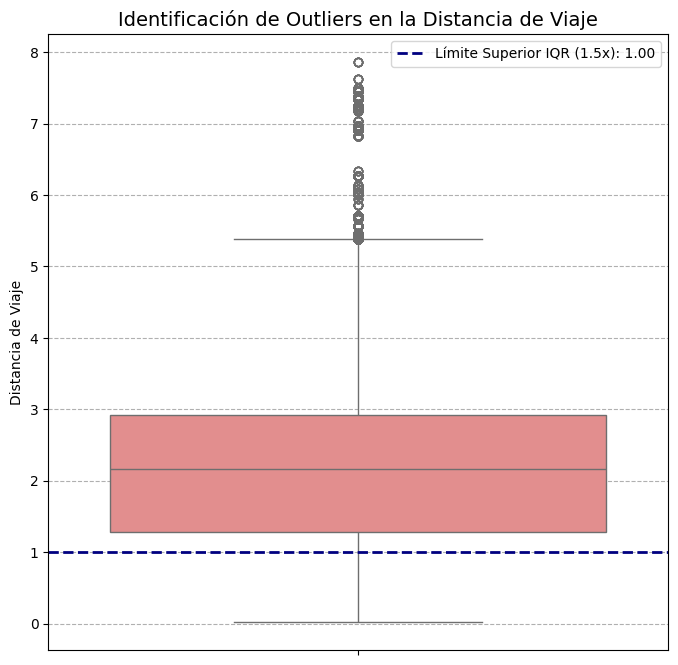

In [ ]:

# Generación del Boxplot 
plt.figure(figsize=(8, 8))
sns.boxplot(y=df_final['distance'], color='lightcoral')
# Marcamos el límite superior para visualizar el umbral
plt.axhline(limite_superior, color='navy', linestyle='--', linewidth=2, 
            label=f'Límite Superior IQR (1.5x): {limite_superior:.2f}')

plt.title(f'Identificación de Outliers en la Distancia de Viaje', fontsize=14)
plt.ylabel('Distancia de Viaje')
plt.xlabel('') # Quitamos la etiqueta X ya que solo hay una variable
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--')
plt.show()

# El servicio se utiliza principalmente para traslados cortos. Los pocos viajes 
# muy largos son los que dan la gran extensión al dataset y deben tratarse para 
# obtener un promedio de distancia preciso.


### Calculos de Outiers de Price 

In [47]:
promedio_price=df_final['price'].mean()
moda_price=df_final['price'].mode()
mediana_price=df_final['price'].median()

# presentamos los valores 
print("Promedio de price:" , promedio_price)
print("moda de price:" , promedio_price)
print("mediana de price:" , promedio_price)

Promedio de price: 16.54512549061407
moda de price: 16.54512549061407
mediana de price: 16.54512549061407


#### Calculo del IQR Price

In [ ]:
#Calculo de IQR en distance 
q1=df_paseo['price'].quantile(0.25)
q3=df_paseo['price'].quantile(0.75)
iqr= q3-q1

limite_inferior= q1 -1.5 *iqr
limite_superior=q3 +1.5 *iqr

outliers= df_final[(df_final['price']< limite_inferior) | (df_paseo['price']>limite_superior)]

print(f"Total de Outliers detectados en 'price': {len(outliers)}")



Total de Outliers detectados en 'price': 5589


### Gráfica de Price

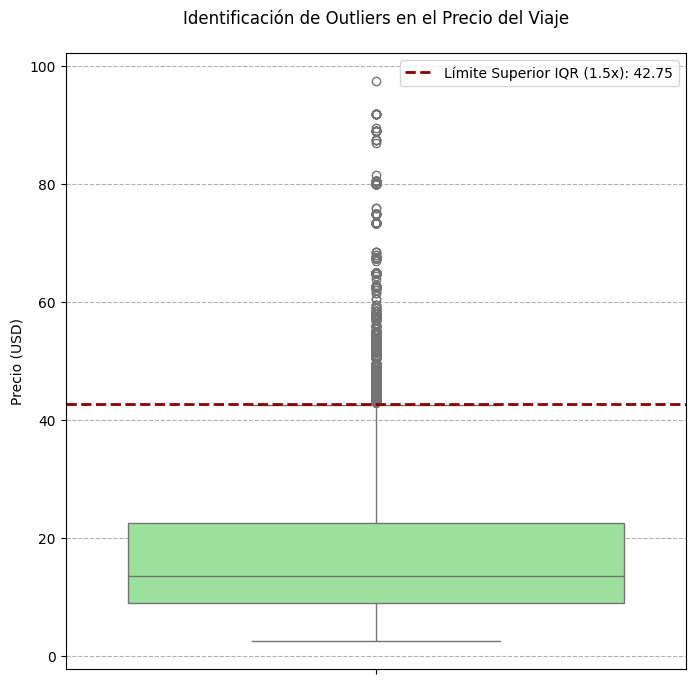


--- Métricas Clave para el Precio ---
Mediana (50%): 13.50
Límite Superior IQR: 42.75


In [ ]:
# --- 2. Generación del Boxplot ---
plt.figure(figsize=(8, 8))
sns.boxplot(y=df_final['price'], color='lightgreen')

# Marcamos el límite superior para visualizar el umbral
plt.axhline(limite_superior, color='darkred', linestyle='--', linewidth=2, 
            label=f'Límite Superior IQR (1.5x): {limite_superior:.2f}')

plt.title(f'Identificación de Outliers en el Precio del Viaje\n')
plt.ylabel('Precio (USD)')
plt.xlabel('')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--')
plt.show()

print(f"\n--- Métricas Clave para el Precio ---")
print(f"Mediana (50%): {df_final['price'].median():.2f}")
print(f"Límite Superior IQR: {limite_superior:.2f}")

#El precio es muy predeciblemente bajo, pero los pocos 
#viajes caros inflan el promedio y generan la mayor variabilidad.

C:\Users\OZZFEST\AppData\Local\Temp\ipykernel_5812\556121010.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='price', data=df_final, palette='coolwarm')


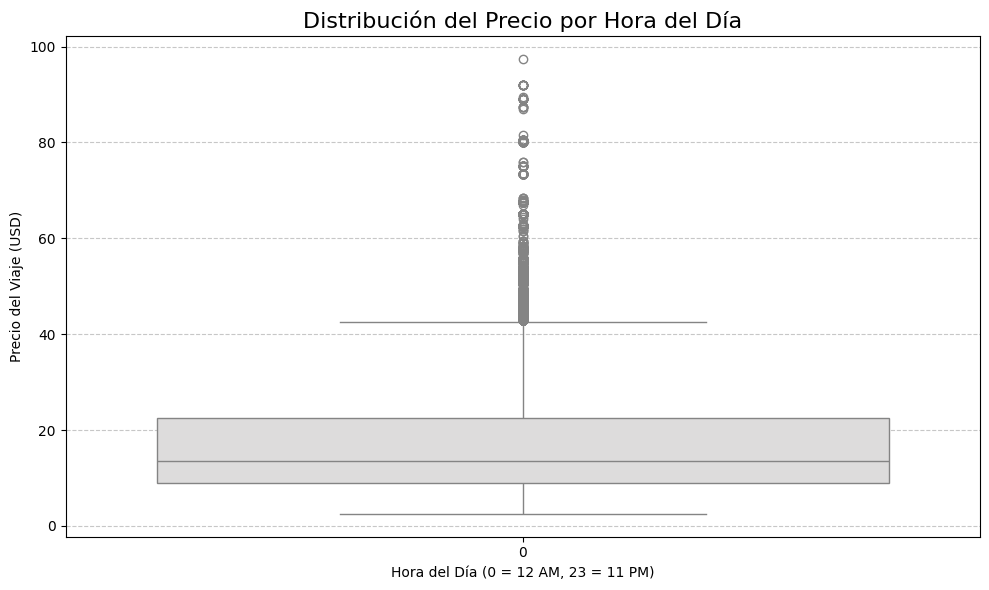

In [ ]:

time_column = 'time_stamp_viaje' if 'time_stamp_viaje' in df_final.columns else 'time_stamp'

# 1. Extraer la hora del día
df_final['hour'] = df_final[time_column].dt.hour

# 2. Calcular el conteo de viajes por cada hora
df_hourly_counts = df_final['hour'].value_counts().reset_index()
df_hourly_counts.columns = ['hour', 'count']

plt.figure(figsize=(10, 6))
sns.boxplot(x='hour', y='price', data=df_final, palette='coolwarm')

plt.title('Distribución del Precio por Hora del Día', fontsize=16)
plt.xlabel('Hora del Día (0 = 12 AM, 23 = 11 PM)')
plt.ylabel('Precio del Viaje (USD)')
plt.xticks(rotation=0) # Mantenemos las etiquetas de hora sin rotar
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# El precio del viaje tiene un valor estable y bajo (la caja), 
# pero la alta demanda genera picos de precio (los outliers) que son los que causan 
# la mayor variación que se ve en el gráfico. La hora del día es el detonante de esta variabilidad.


price: Es común encontrar valores atípicos (precios muy altos) que podrían ser viajes largos, errores de registro, o precios con surge multiplier extremo.

distance: Viajes extremadamente largos o muy cortos.

temp_clima: Temperaturas fuera del rango esperado para la región pueden indicar errores del sensor o outliers de unión.

Los outliers pueden distorsionar las medidas de tendencia central (media) y afectar la precisión de modelos predictivos (regresión).


--- Detección de Outliers (Price y Distance) ---


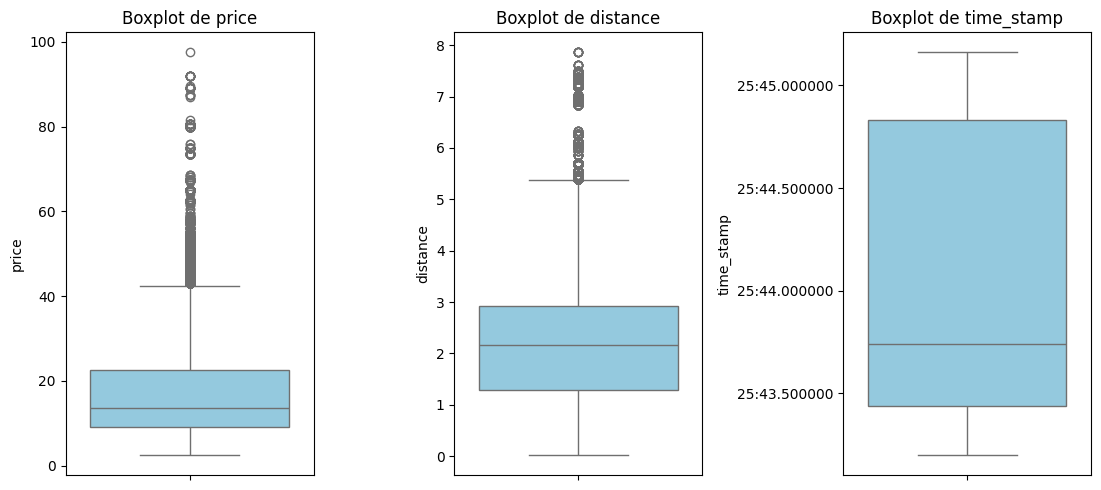

In [88]:
print("\n--- Detección de Outliers (Price y Distance) ---")

# Seleccionar variables numéricas clave
variables_numericas = ['price', 'distance', 'time_stamp']

plt.figure(figsize=(15, 5))

for i, col in enumerate(variables_numericas):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(y=df_final[col], color='skyblue')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

# Distribución de las variables

 La mayoría de los precios de servicios suelen tener una distribución sesgada a la derecha (mayoría de viajes baratos y pocos muy caros). Esto es un patrón común en datos de precios.

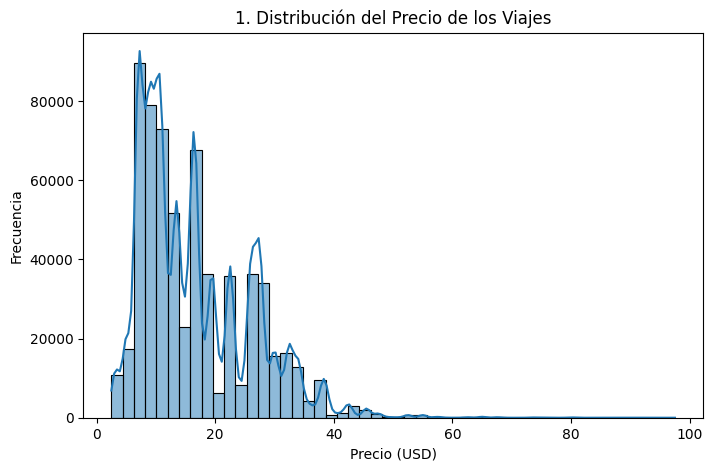

In [ ]:
# Histograma para ver la forma de la distribución del precio
plt.figure(figsize=(8, 5))
sns.histplot(df_final['price'].dropna(), kde=True, bins=50) # Usamos dropna() para ignorar nulos
plt.title('1. Distribución del Precio de los Viajes')
plt.xlabel('Precio (USD)')
plt.ylabel('Frecuencia')
plt.show()

#Este gráfico confirma el sesgo positivo extremo (lo que hace que la media sea más alta que la moda). 
#La mayoría de los viajes son muy baratos, y solo unos pocos se acercan a precios de $40 USD o más. 
#El patrón "dentado" (picos y valles) puede indicar una preferencia por precios redondos 
#($10, $15, $20) o la estructura de precios fija de los diferentes tipos de vehículos.

Un gráfico de barras muestra el balance de los datos categóricos. Es fundamental saber si el dataset tiene un desbalance en la oferta ej. muchos más viajes de Uber que de Lyft, o viceversa, lo cual podría influir en cualquier análisis de comparación.

C:\Users\OZZFEST\AppData\Local\Temp\ipykernel_5812\4006283575.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


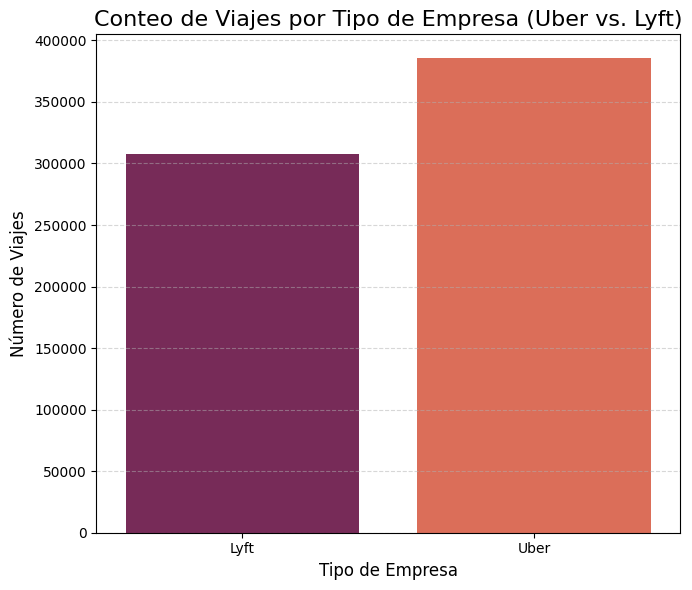

In [ ]:
columna_analizar = 'cab_type'
plt.figure(figsize=(7, 6))
ax = sns.countplot(
    x=columna_analizar, 
    data=df_final, 
    palette='rocket'
)
ax.set_title('Conteo de Viajes por Tipo de Empresa (Uber vs. Lyft)', fontsize=16)
ax.set_xlabel('Tipo de Empresa', fontsize=12)
ax.set_ylabel('Número de Viajes', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# La oferta de viajes no está perfectamente balanceada, pero sí es bastante competitiva, 
# con Uber llevando una ligera ventaja en el volumen total de viajes en este período. Esto es 
# crucial para analizar la estrategia de precios de cada competidor.

Un gráfico de dispersión es ideal para buscar correlaciones o patrones entre dos variables numéricas. Queremos ver si las temperaturas extremas muy frío o muy cálido o las temperaturas confortables se asocian a precios más altos o más bajos debido a la demanda 

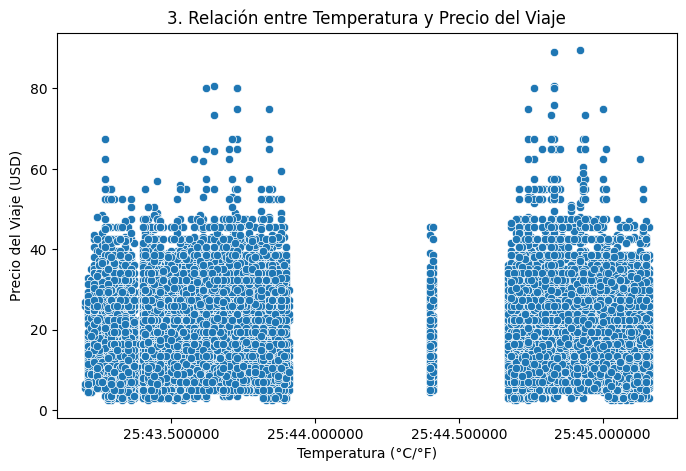

In [ ]:
# Gráfico de dispersión para la relación entre dos variables numéricas
plt.figure(figsize=(8, 5))
sns.scatterplot(x='time_stamp', y='price', data=df_final.sample(frac=0.1)) # Se usa muestra (sample) por el gran volumen de datos
plt.title('3. Relación entre Temperatura y Precio del Viaje')
plt.xlabel('Temperatura (°C/°F)')
plt.ylabel('Precio del Viaje (USD)')
plt.show()

# La temperatura no tiene una correlación lineal simple y directa con el precio. 
# Si bien el clima puede influir en la demanda, el precio está mucho más influenciado 
# por el surge_multiplier y la distancia que por la temperatura ambiente.


In [105]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   distance          693071 non-null  float64       
 1   cab_type          693071 non-null  object        
 2   time_stamp        693071 non-null  datetime64[ns]
 3   destination       693071 non-null  object        
 4   price             637976 non-null  float64       
 5   surge_multiplier  693071 non-null  int64         
 6   id                693071 non-null  object        
 7   product_id        693071 non-null  object        
 8   name              693071 non-null  object        
 9   temp              693071 non-null  float64       
 10  clouds            693071 non-null  float64       
 11  pressure          693071 non-null  float64       
 12  rain              693071 non-null  float64       
 13  humidity          693071 non-null  float64       
 14  wind